## Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

## Load cleaned dataset

In [2]:
PROJECT_ROOT = Path.cwd()

for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (parent / "README.md").exists() and (parent / "data").exists():
        PROJECT_ROOT = parent
        break

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cleaned_dataset.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{DATA_PATH}\n"
        "Run Notebook 02 first."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded.")
print(f"Shape: {df.shape}")

Dataset loaded.
Shape: (278701, 39)


In [3]:
display(df.head())
display(df.sample(5, random_state=42))

,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,hba1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,0.0,5.8,158.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,0.0,6.6,159.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,0.0,4.0,126.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,0.0,6.2,85.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,0.0,5.7,155.0,214.703704,6.864403,246.703704,High,No,High,Yes,Yes,152.481481,No,Low,8.219098,11.168096,135.380192,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,heart_disease,hba1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,family_history,stress_level,low_hdl_cholesterol,high_ldl_cholesterol,blood_pressure,high_blood_pressure,sugar_consumption,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
251858,Middle_Female_Obese_Current_Yes,Middle,Female,Obese,Current,Yes,38,0.413793,34.30,0.142857,0.042857,7.002857,194.0,235.000000,8.400000,75.000000,Moderate,No,High,No,Yes,151.015000,No,Medium,7.461950,12.371993,169.00000,117.000000,25.700000,4.500000,73.000000,59.000000,150.000000,Primary,Employed,hypertension,"1,0,1",DI_HY,Abnormal
76122,Senior_Male_Overweight_Never_Yes,Senior,Male,Overweight,Never,Yes,75,0.839080,25.76,0.000000,0.000000,6.800000,280.0,226.851852,7.336583,246.277778,High,Yes,High,Yes,Yes,148.518519,Yes,Low,6.695729,12.251526,134.40771,89.800234,14.832009,8.418458,75.221963,65.725467,130.405374,Tertiary,Employed,diabetes,"1,0,0",DI,Abnormal
82692,Young_Male_Underweight_Never_No,Young,Male,Underweight,Never,No,10,0.091954,15.92,0.000000,0.000000,4.800000,100.0,228.130653,7.080402,156.115578,Moderate,Yes,Low,No,Yes,150.269231,No,Medium,7.824534,11.846610,133.01005,87.839196,14.957789,8.387940,74.120603,65.713568,131.542714,Tertiary,Employed,diabetes,"0,0,0",N,Normal
155872,Mature_Female_Obese_Former_Yes,Mature,Female,Obese,Former,Yes,67,0.747126,38.20,0.281330,0.117647,6.950128,85.0,189.000000,5.700000,90.000000,Low,No,Medium,No,Yes,150.720942,Yes,High,7.458483,12.384471,158.00000,78.000000,4.700000,3.900000,54.000000,91.000000,159.000000,Secondary,Employed,hypertension,"1,0,1",DI_HY,Abnormal
167837,Middle_Male_Normal_Never_Yes,Middle,Male,Normal,Never,Yes,45,0.494252,22.30,0.133333,0.133333,7.053333,101.0,182.000000,4.400000,232.000000,High,Yes,Low,No,Yes,151.265625,No,Medium,6.948041,12.518972,124.00000,101.000000,6.400000,14.500000,61.000000,72.000000,131.000000,Secondary,Retired,hypertension,"1,0,1",DI_HY,Abnormal


In [4]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Numerical columns: {len(numeric_cols)}")

display(
    df[numeric_cols]
    .describe()
    .T
)

Numerical columns: 20


,count,mean,std,min,25%,50%,75%,max
age,278701.0,49.710381,21.682385,2.000000,32.000000,50.000000,68.000000,89.000000
age_normalized,278701.0,0.548395,0.249223,0.000000,0.344827,0.551724,0.758620,1.000000
bmi,278701.0,27.492328,7.068966,10.010000,22.010000,27.320000,32.700000,95.690000
hypertension,278701.0,0.129193,0.187602,0.000000,0.000000,0.071823,0.217063,1.000000
heart_disease,278701.0,0.073945,0.138504,0.000000,0.000000,0.007800,0.117647,1.000000
hba1c_level,278701.0,5.951910,0.952495,3.500000,5.387500,5.800000,6.865766,9.000000
glucose,278701.0,135.267784,38.503495,70.000000,100.000000,137.000000,160.000000,300.000000
cholesterol,278701.0,224.027190,35.668600,150.000000,201.000000,225.000000,243.000000,300.000000
sleep_hours,278701.0,6.954743,1.432179,4.000000,6.196679,6.975185,7.700000,10.000000
triglycerides,278701.0,178.540442,67.344842,50.000000,128.000000,178.000000,241.750000,400.000000


In [5]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")

categorical_summary = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [
        df[col].nunique(dropna=False)
        for col in categorical_cols
    ]
})

display(categorical_summary)

/tmp/ipykernel_13975/3710473352.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


Categorical columns: 19


,column,unique_values
0,composite_key,192
1,age_level,4
2,gender,2
3,bmi_level,4
4,smoking,3
5,diabetes,2
6,physical_activity,3
7,family_history,2
8,stress_level,3
9,low_hdl_cholesterol,2


## Numerical distributions

In [6]:
important_numeric = [
    "age",
    "bmi",
    "glucose",
    "hba1c",
    "systolic_bp",
    "diastolic_bp",
    "cholesterol",
    "hdl",
    "ldl",
    "triglycerides",
    "heart_rate",
    "crp",
    "homocysteine"
]

available_numeric = [
    col for col in important_numeric
    if col in df.columns
]

print("Available health variables:")
print(available_numeric)

Available health variables:
['age', 'bmi', 'glucose', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'hdl', 'ldl', 'triglycerides', 'heart_rate']


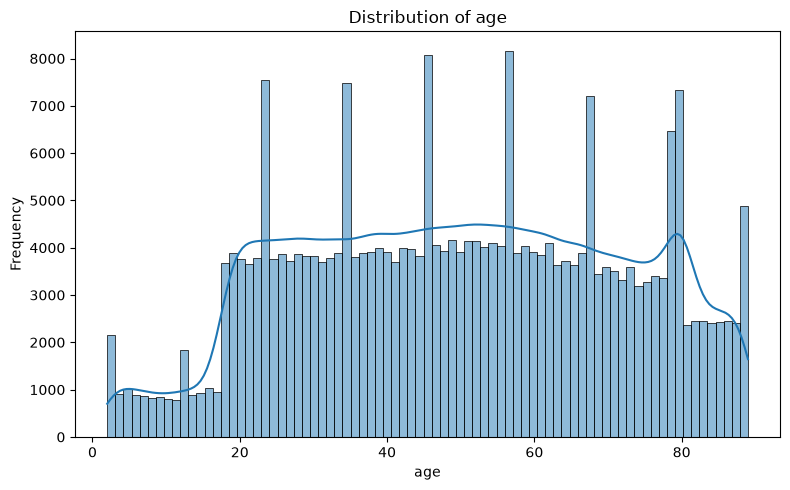

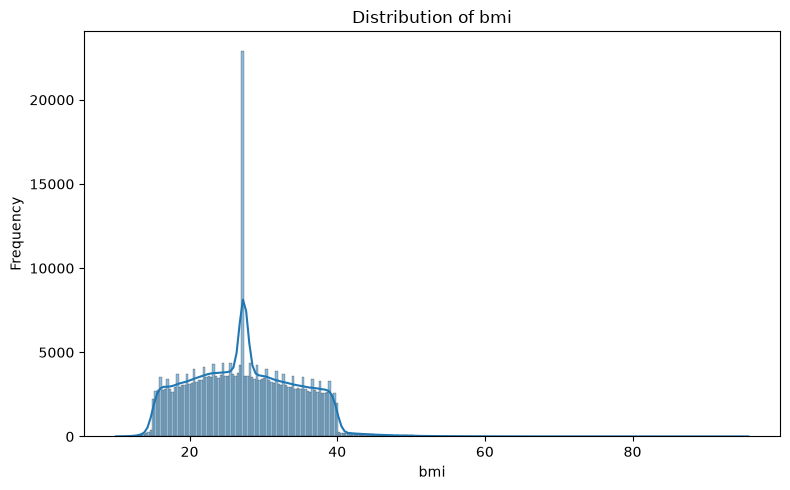

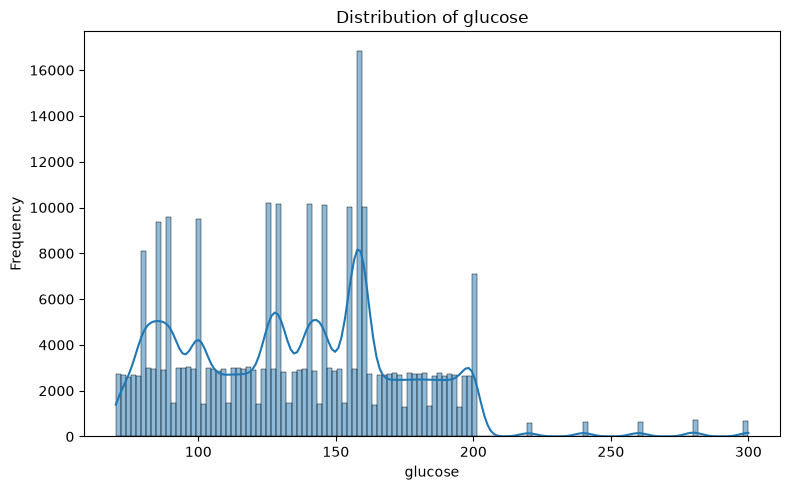

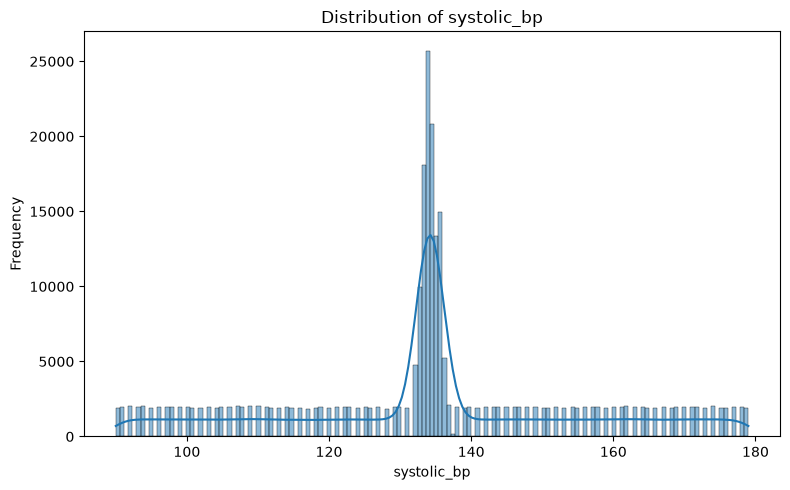

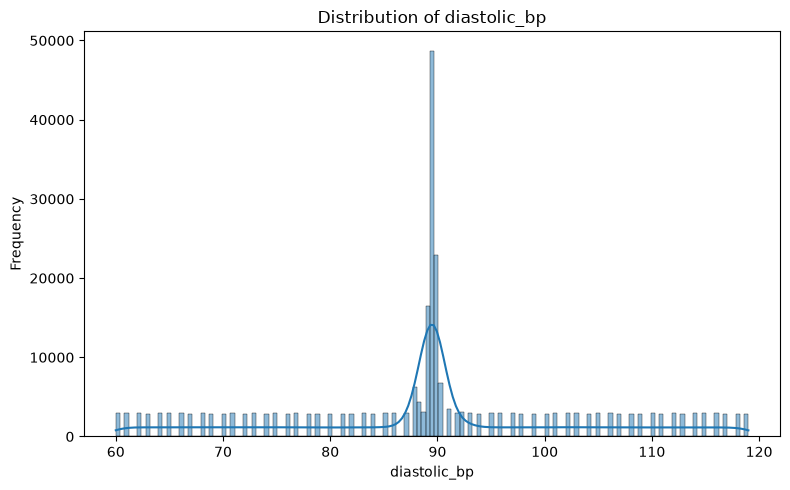

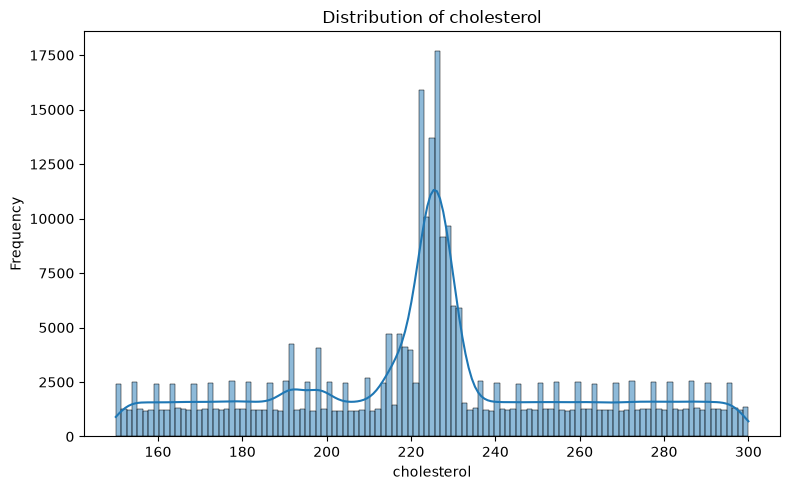

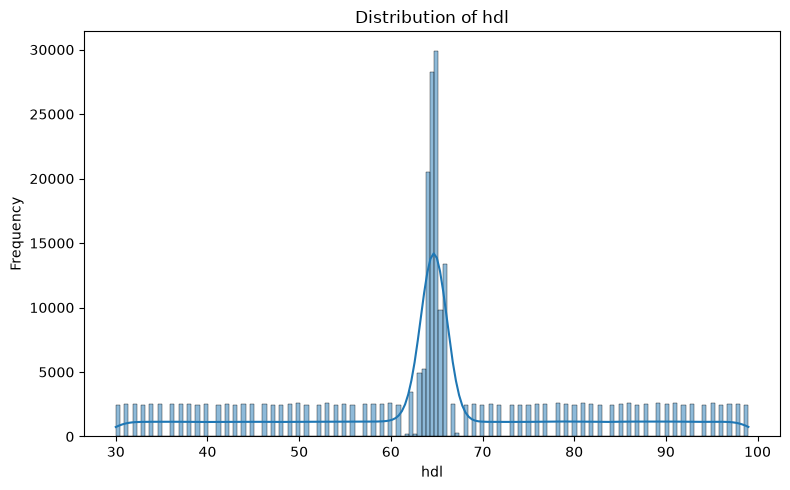

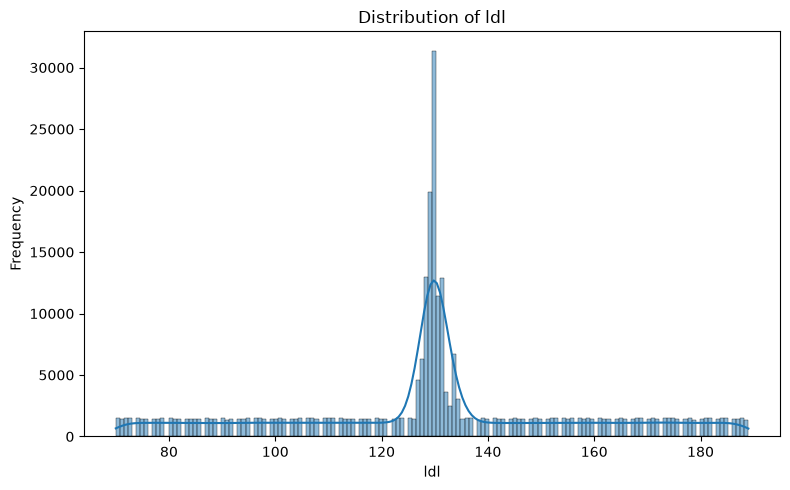

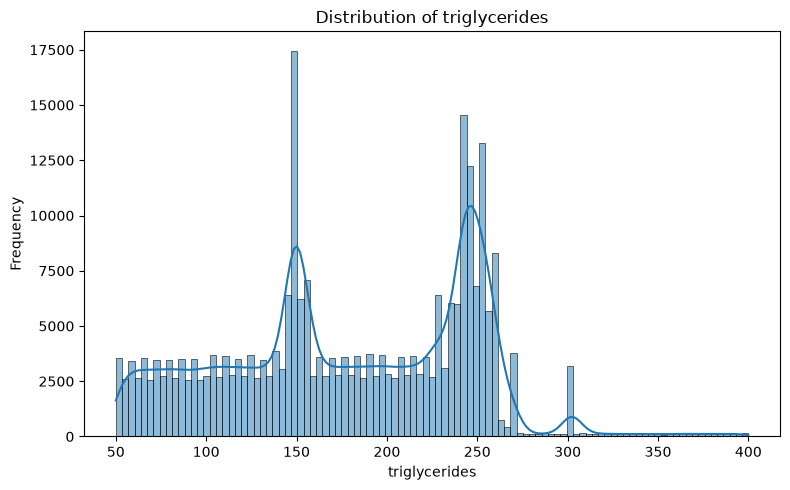

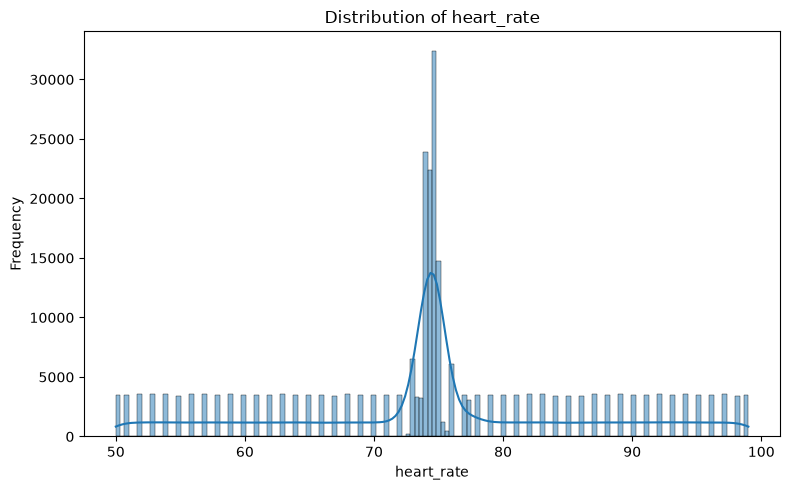

In [7]:
for col in available_numeric:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## Categorical distributions

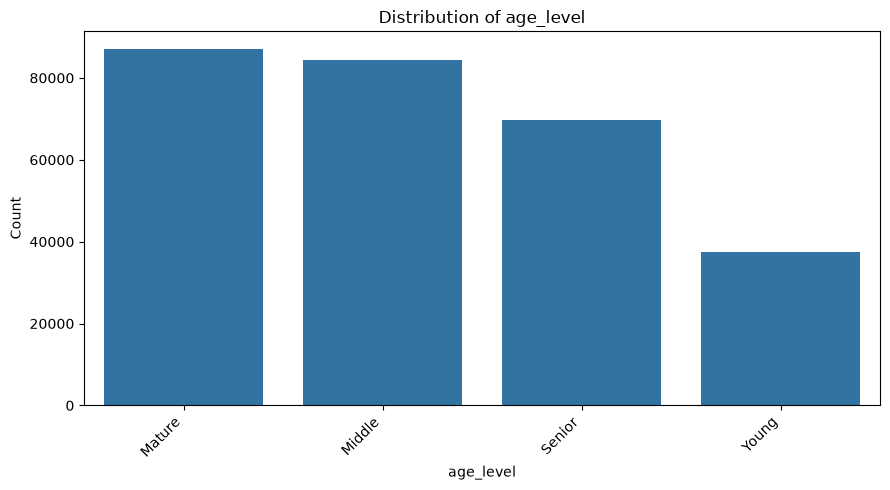

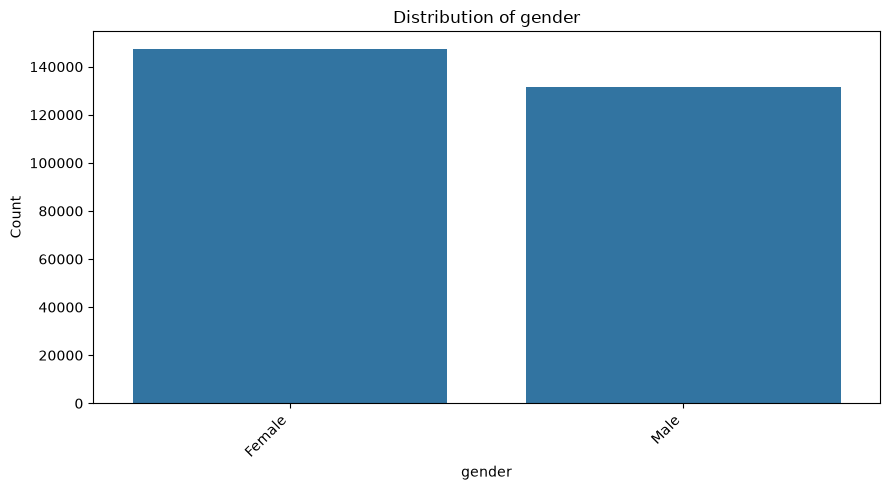

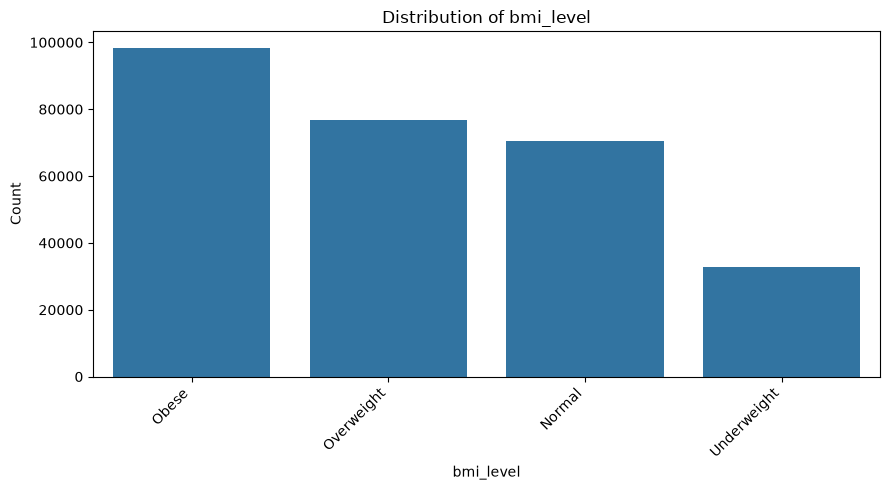

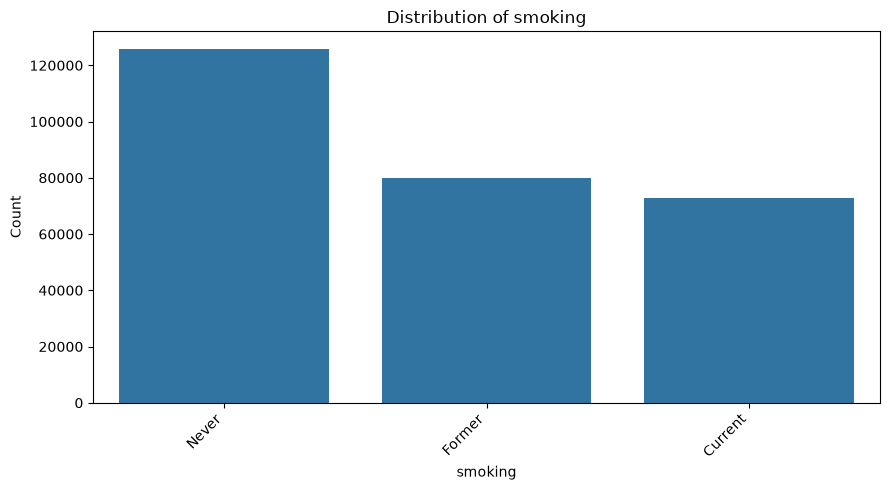

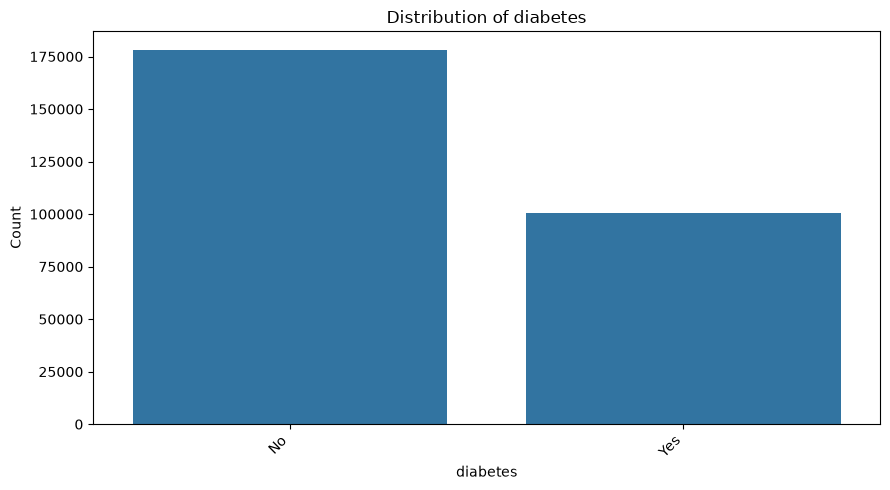

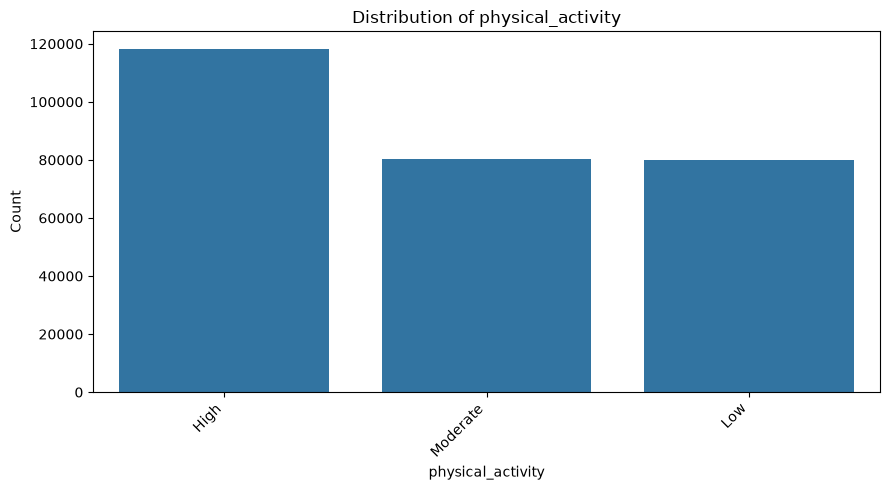

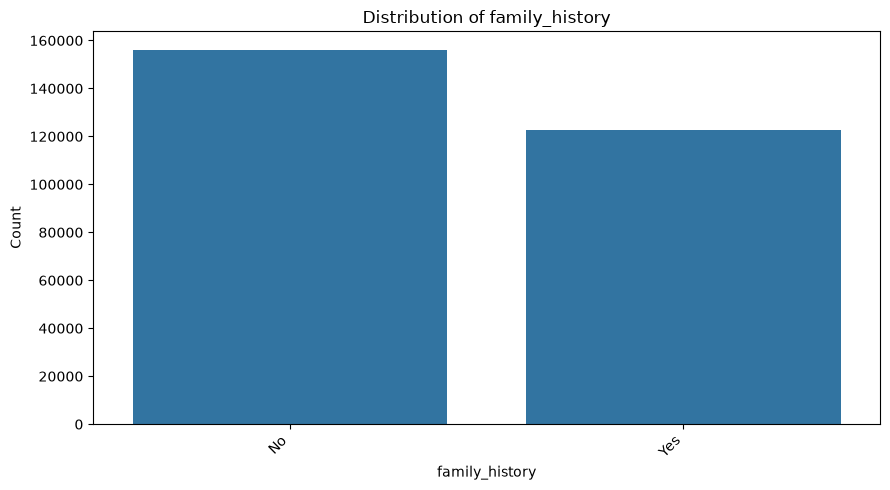

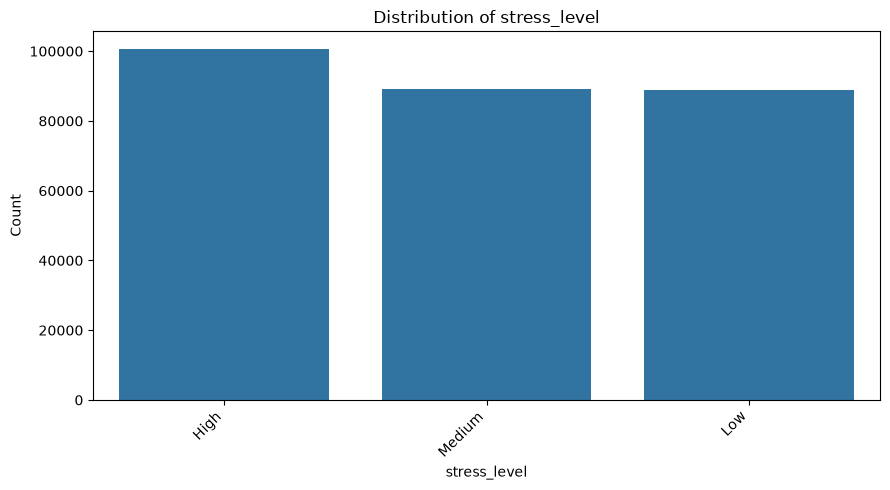

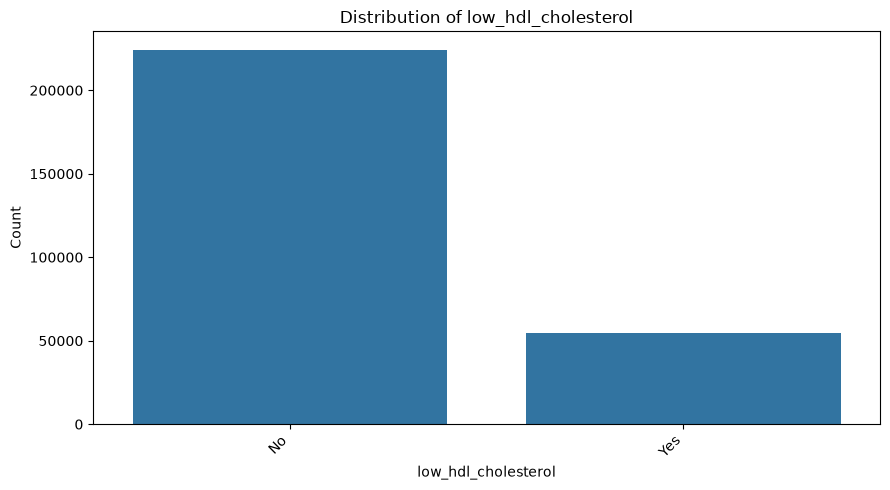

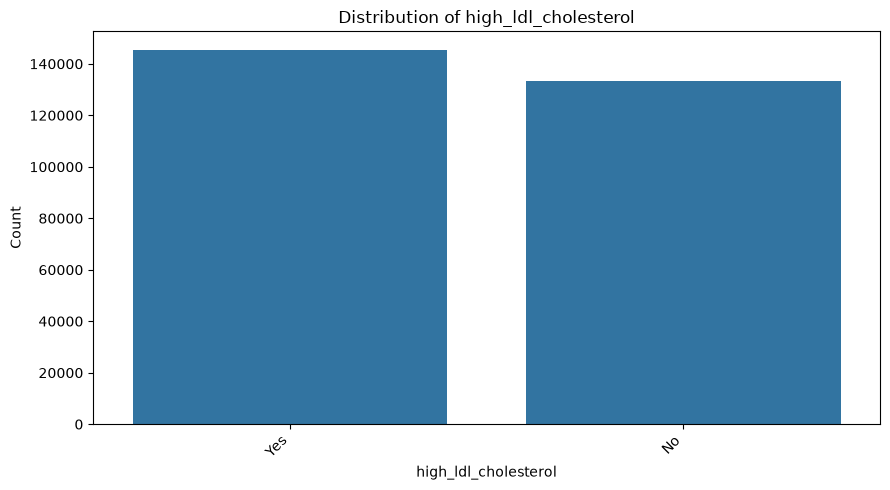

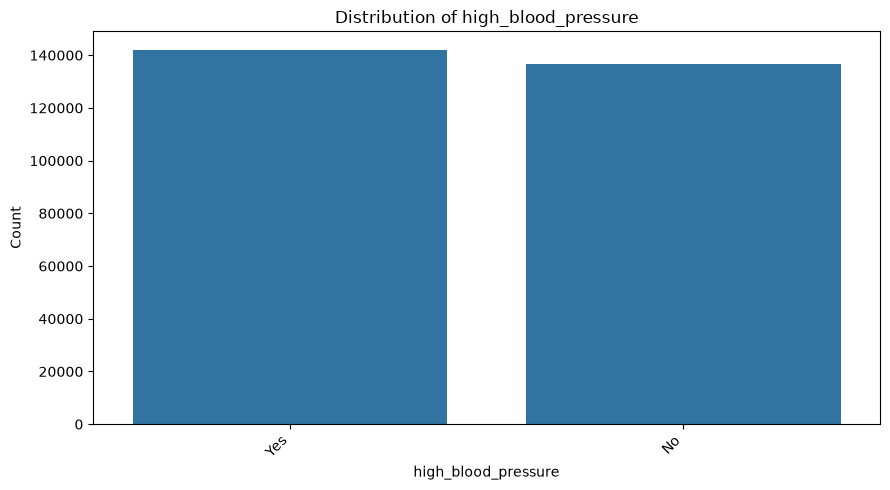

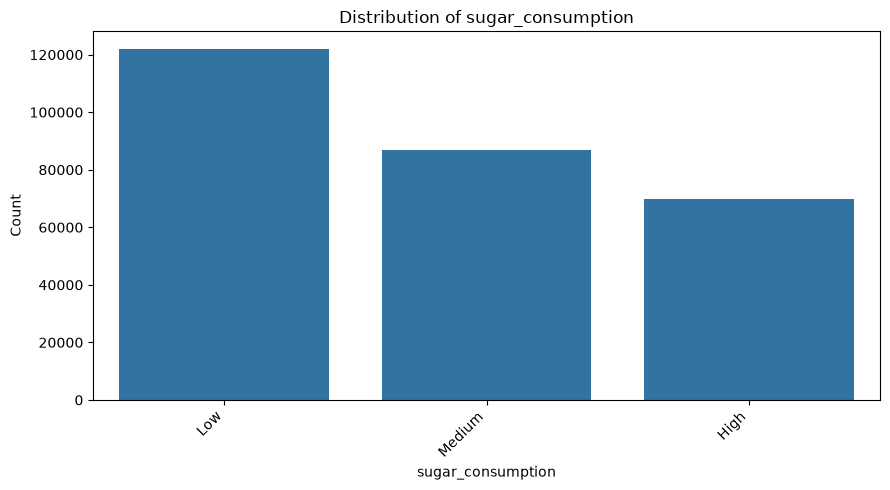

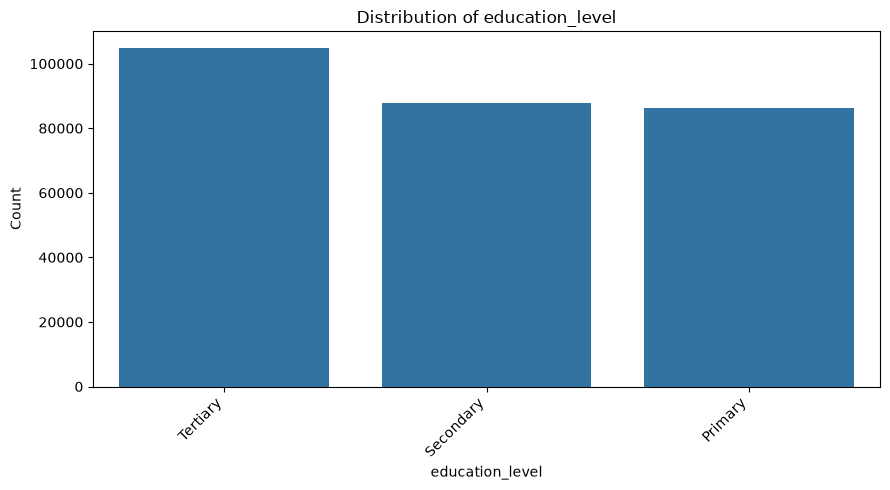

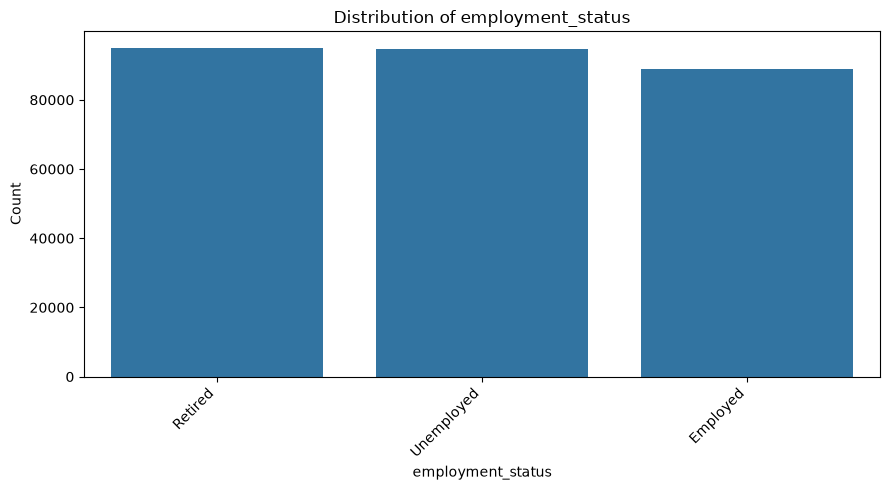

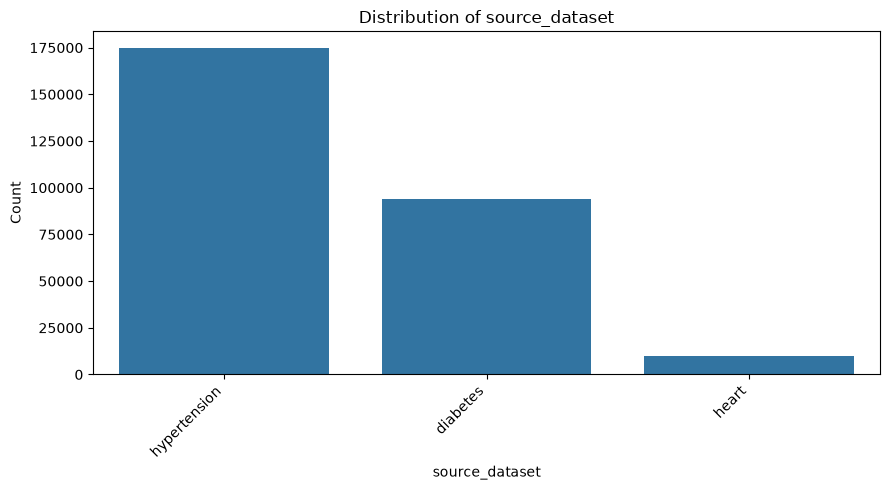

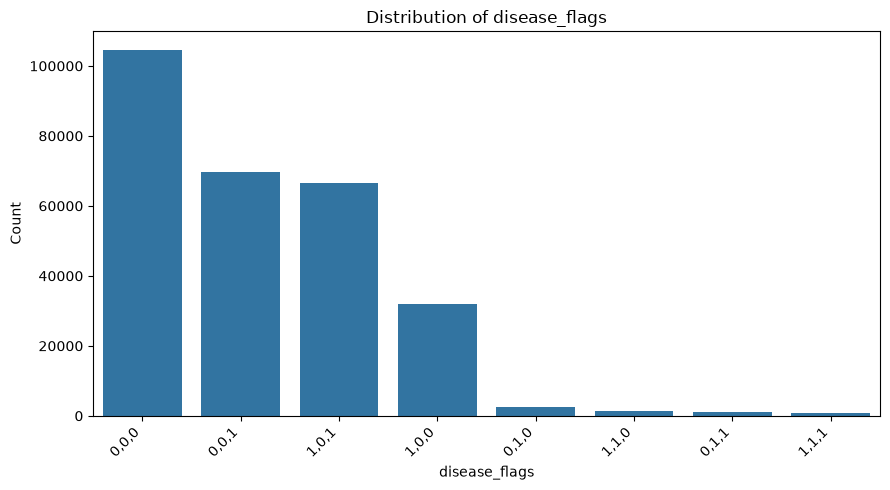

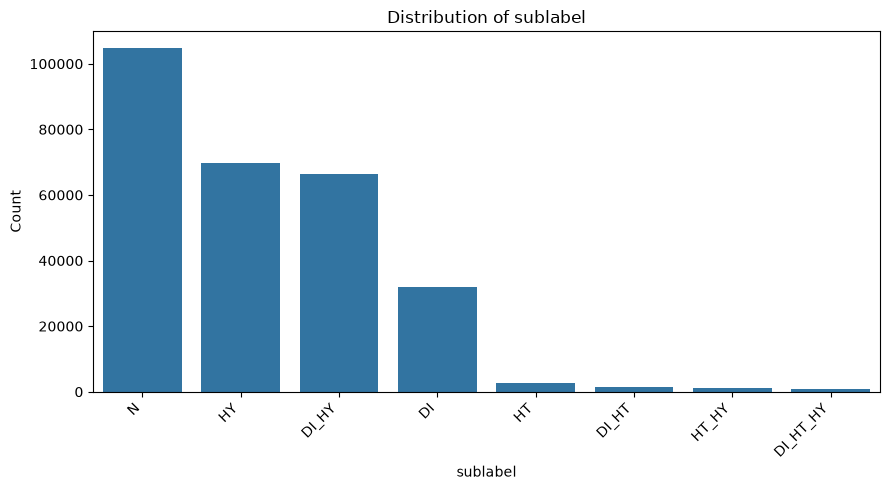

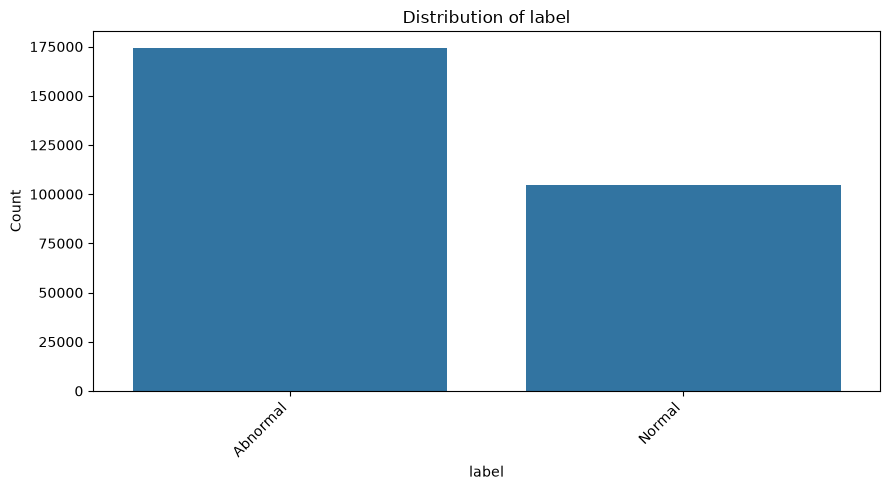

In [8]:
for col in categorical_cols:

    # Avoid plotting high-cardinality columns
    if df[col].nunique(dropna=False) <= 20:

        plt.figure(figsize=(9, 5))

        order = df[col].value_counts(
            dropna=False
        ).index

        sns.countplot(
            data=df,
            x=col,
            order=order
        )

        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## Target distributions

In [9]:
target_columns = [
    "diabetes",
    "hypertension",
    "heart_disease",
    "bmi_level"
]

available_targets = [
    col for col in target_columns
    if col in df.columns
]

print("Targets available for exploration:")
print(available_targets)

Targets available for exploration:
['diabetes', 'hypertension', 'heart_disease', 'bmi_level']


In [11]:
for target in available_targets:

    print(target.upper())
    print("_" * 70 + "\n")

    distribution = (
        df[target]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    distribution["percentage"] = (
        distribution["count"] / len(df) * 100
    )

    display(distribution)

DIABETES
______________________________________________________________________



,count,percentage
diabetes,,
No,178083,63.89751
Yes,100618,36.10249


HYPERTENSION
______________________________________________________________________



,count,percentage
hypertension,,
0.000000,104044,37.331764
1.000000,8060,2.891988
0.333333,3597,1.290630
0.142857,3215,1.153566
0.217391,3141,1.127014
...,...,...
0.211864,240,0.086114
0.003086,230,0.082526
0.000300,199,0.071403


HEART_DISEASE
______________________________________________________________________



,count,percentage
heart_disease,,
0.000000,119385,42.836230
1.000000,3910,1.402937
0.222222,3845,1.379615
0.032258,3074,1.102974
0.080000,3040,1.090775
...,...,...
0.000776,255,0.091496
0.218220,240,0.086114
0.000300,199,0.071403


BMI_LEVEL
______________________________________________________________________



,count,percentage
bmi_level,,
Obese,98377,35.298402
Overweight,76897,27.591218
Normal,70591,25.328578
Underweight,32836,11.781802


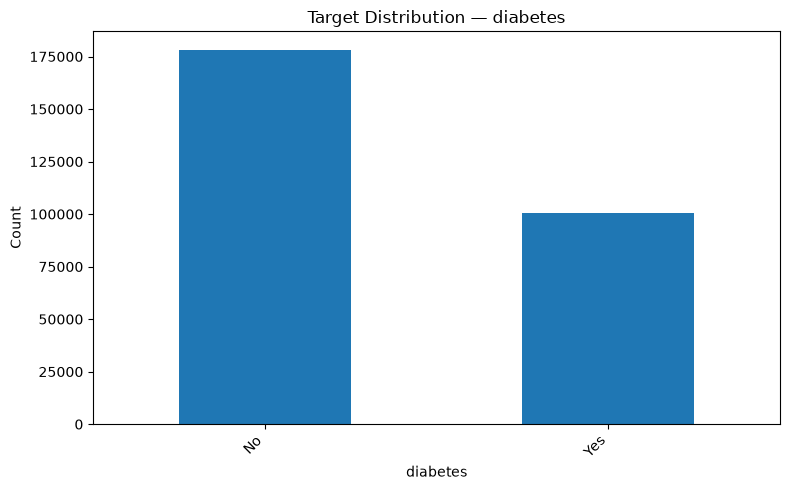

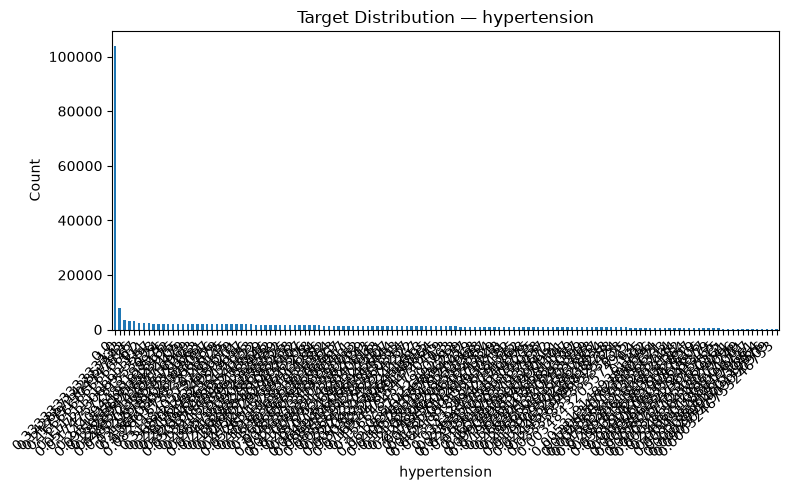

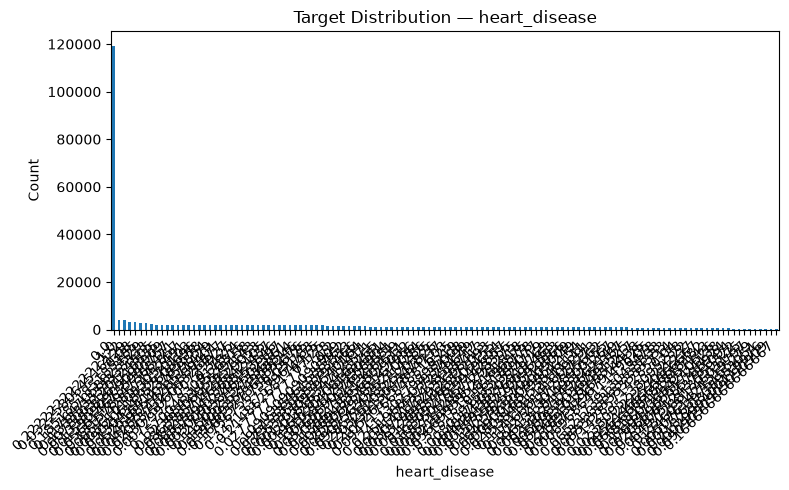

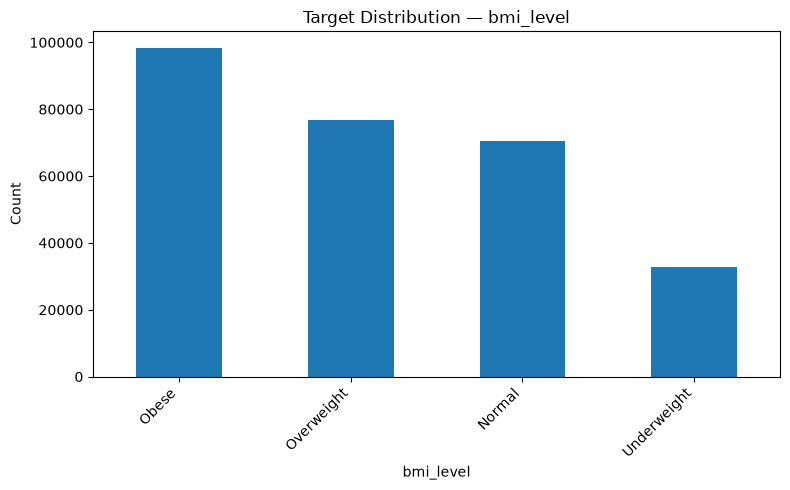

In [12]:
for target in available_targets:

    counts = df[target].value_counts(dropna=False)

    plt.figure(figsize=(8, 5))

    counts.plot(kind="bar")

    plt.title(f"Target Distribution — {target}")
    plt.xlabel(target)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Diabetes EDA

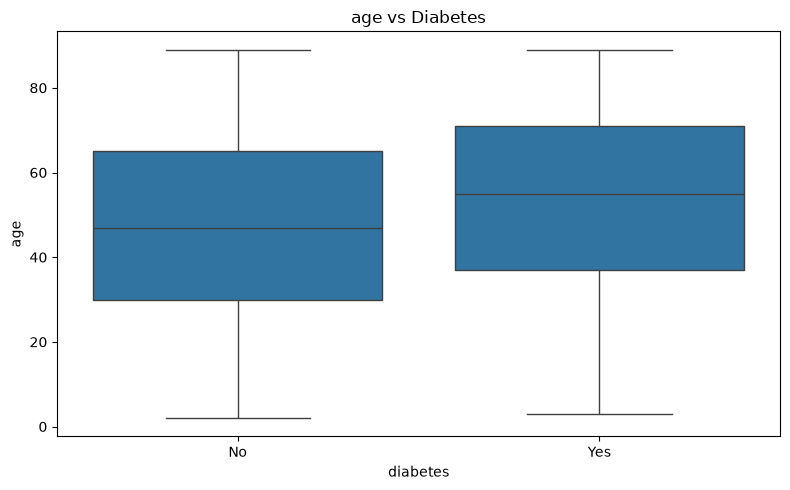

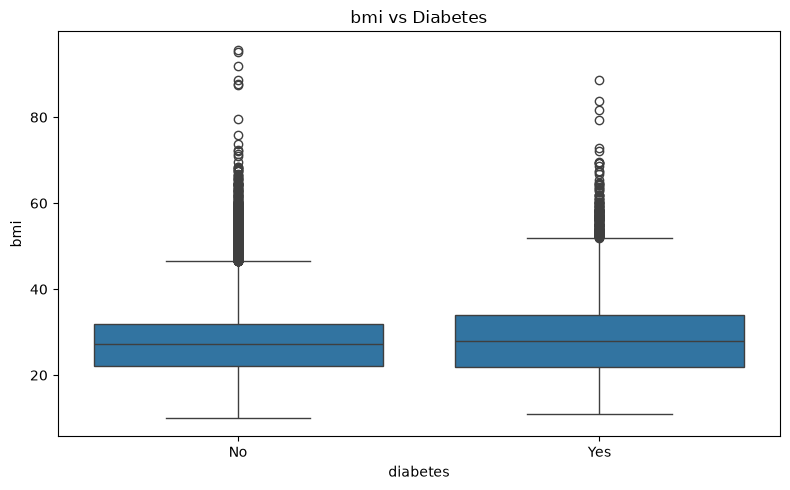

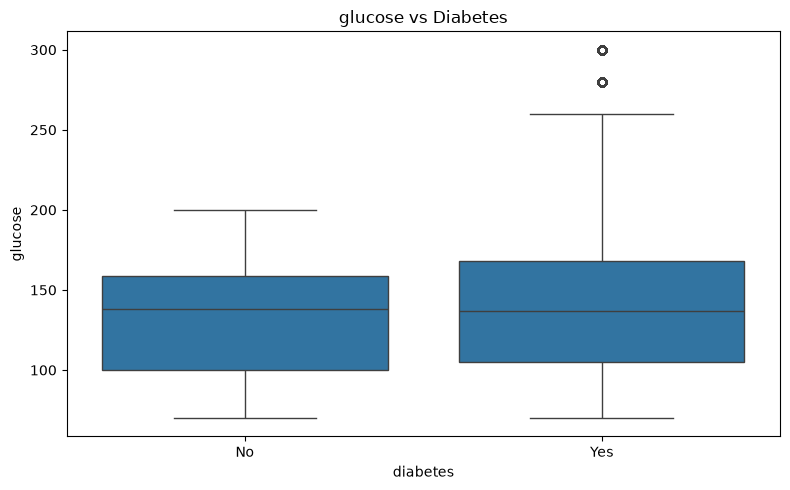

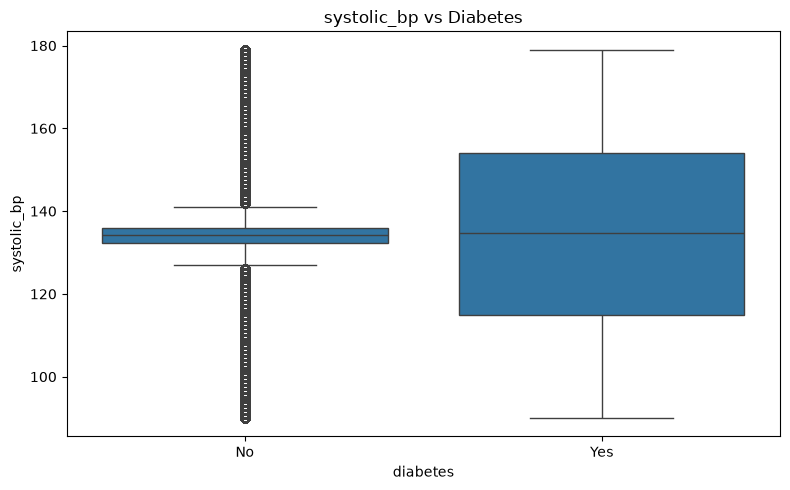

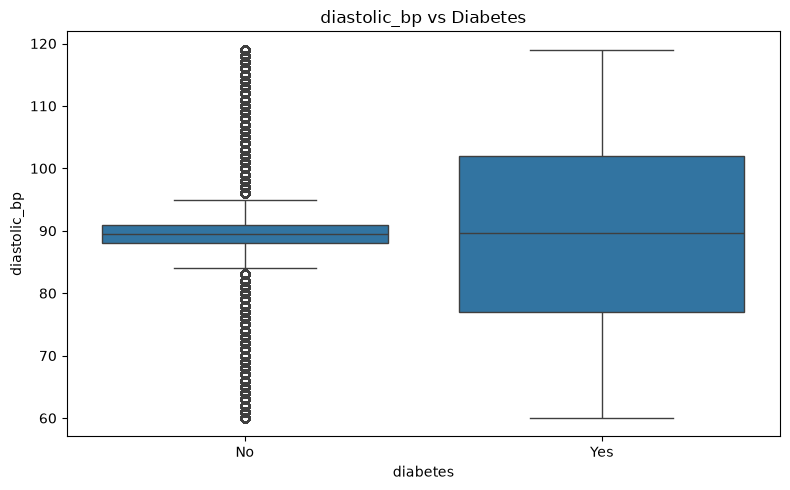

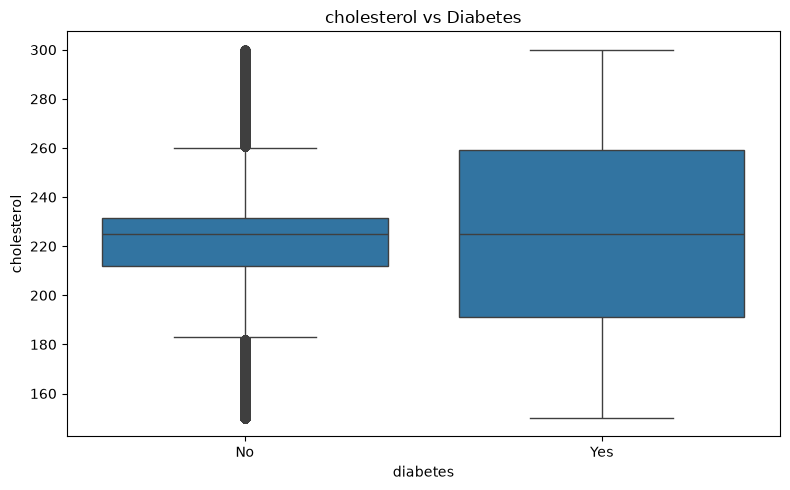

In [13]:
if "diabetes" in df.columns:

    diabetes_features = [
        "age",
        "bmi",
        "glucose",
        "hba1c",
        "systolic_bp",
        "diastolic_bp",
        "cholesterol"
    ]

    diabetes_features = [
        col for col in diabetes_features
        if col in df.columns
    ]

    for feature in diabetes_features:

        if pd.api.types.is_numeric_dtype(df[feature]):

            plt.figure(figsize=(8, 5))

            sns.boxplot(
                data=df,
                x="diabetes",
                y=feature
            )

            plt.title(f"{feature} vs Diabetes")
            plt.tight_layout()
            plt.show()

## Hypertension EDA

In [18]:
if "hypertension" in df.columns:

    print("Hypertension dtype:")
    print(df["hypertension"].dtype)

    print("\nNumber of unique values:")
    print(df["hypertension"].nunique())

Hypertension dtype:
float64

Number of unique values:
137


In [21]:
if "heart_disease" in df.columns:

    heart_features = [
        "age",
        "bmi",
        "cholesterol",
        "hdl",
        "ldl",
        "triglycerides",
        "systolic_bp",
        "heart_rate"
    ]

    heart_features = [
        col for col in heart_features
        if col in df.columns
    ]

    if (
        df["heart_disease"].dtype == "object"
        or df["heart_disease"].nunique() <= 10
    ):

        for feature in heart_features:

            if pd.api.types.is_numeric_dtype(df[feature]):

                plt.figure(figsize=(8, 5))

                sns.boxplot(
                    data=df,
                    x="heart_disease",
                    y=feature
                )

                plt.title(f"{feature} vs Heart Disease")
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()

## Obesity EDA

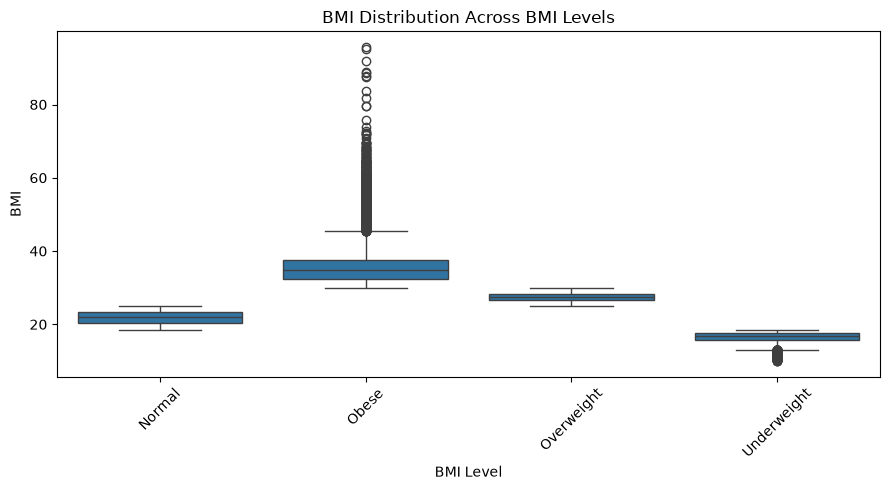

In [20]:
if {"bmi_level", "bmi"}.issubset(df.columns):

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df,
        x="bmi_level",
        y="bmi"
    )

    plt.title("BMI Distribution Across BMI Levels")
    plt.xlabel("BMI Level")
    plt.ylabel("BMI")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Correlation analysis

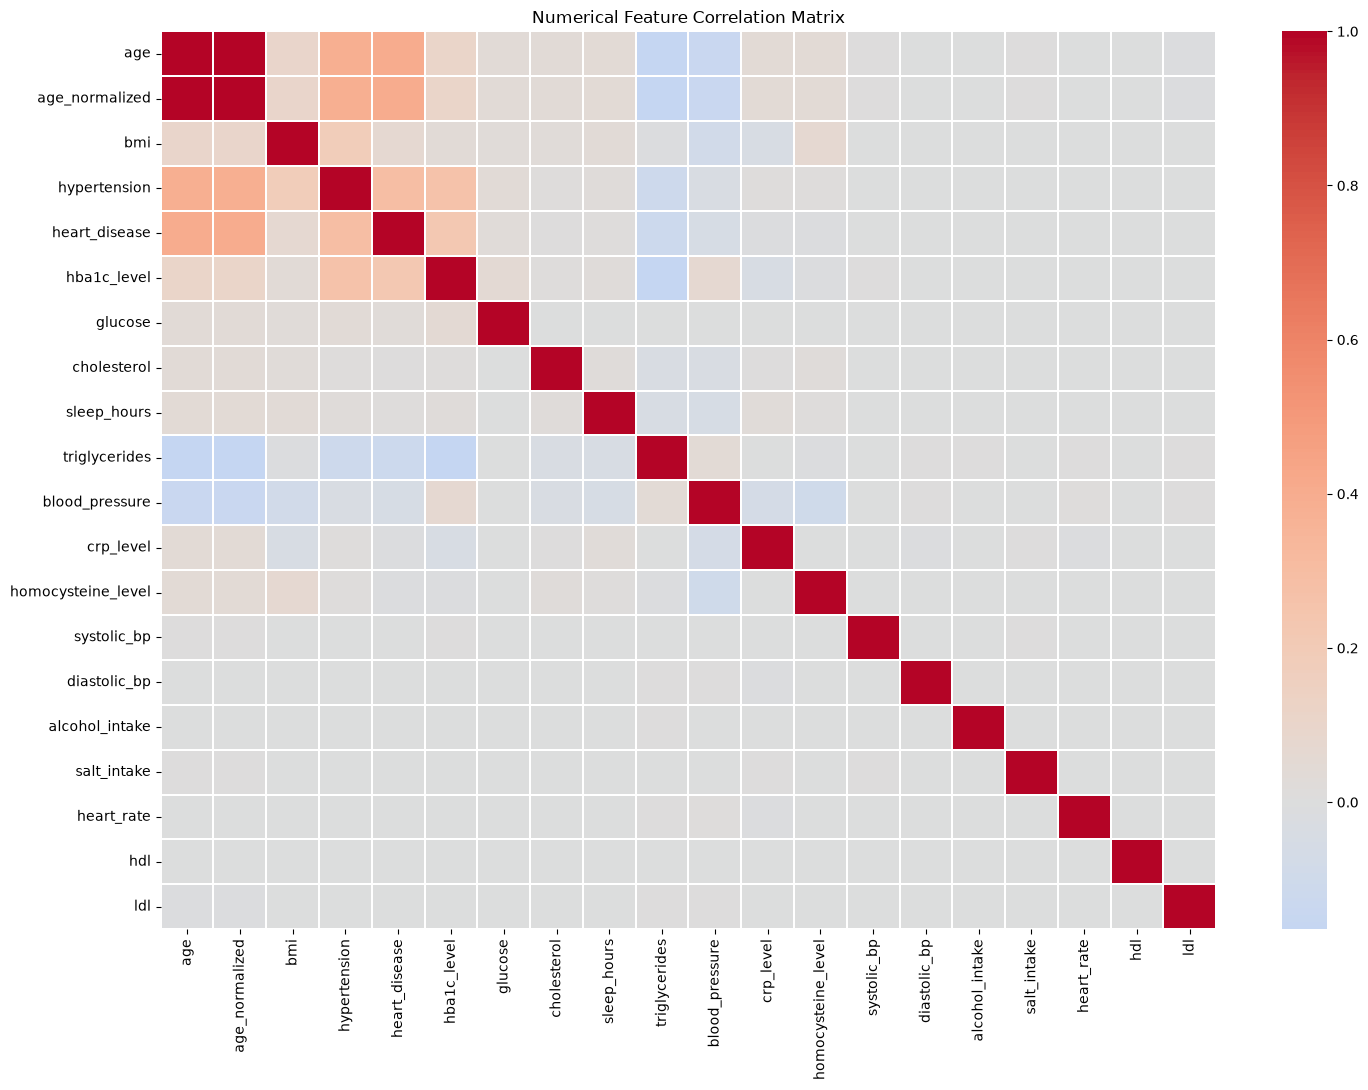

In [22]:
if len(numeric_cols) >= 2:

    correlation_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(15, 11))

    sns.heatmap(
        correlation_matrix,
        cmap="coolwarm",
        center=0,
        linewidths=0.2
    )

    plt.title("Numerical Feature Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [23]:
if len(numeric_cols) >= 2:

    correlation_abs = (
        df[numeric_cols]
        .corr()
        .abs()
    )

    upper_triangle = correlation_abs.where(
        np.triu(
            np.ones(correlation_abs.shape),
            k=1
        ).astype(bool)
    )

    correlation_pairs = (
        upper_triangle
        .stack()
        .sort_values(ascending=False)
    )

    print("Top numerical correlations:")

    display(
        correlation_pairs
        .head(25)
        .to_frame("absolute_correlation")
    )

Top numerical correlations:


absolute_correlation
age            age_normalized                  1.000000
               heart_disease                   0.404749
age_normalized heart_disease                   0.404749
age            hypertension                    0.389928
age_normalized hypertension                    0.389928
hypertension   heart_disease                   0.290420
               hba1c_level                     0.264882
heart_disease  hba1c_level                     0.223413
bmi            hypertension                    0.185668
age            triglycerides                   0.164922
age_normalized triglycerides                   0.164922
hba1c_level    triglycerides                   0.164800
age_normalized blood_pressure                  0.143549
age            blood_pressure                  0.143549
heart_disease  triglycerides                   0.119623
hypertension   triglycerides                   0.111195
age            hba1c_level                     0.107391
age_normalized hba1c_level                     0.107391
               bmi                             0.099528
age            bmi                             0.099528
blood_pressure homocysteine_level              0.096518
bmi            blood_pressure                  0.091537
hba1c_level    blood_pressure                  0.069411
bmi            heart_disease                   0.069252
               homocysteine_level              0.063008

## Outlier analysis 

In [24]:
outlier_results = []

for col in numeric_cols:

    series = df[col].dropna()

    if len(series) == 0:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (
        (series < lower_bound)
        | (series > upper_bound)
    )

    count = outliers.sum()

    outlier_results.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": count,
        "outlier_percentage": count / len(series) * 100
    })

outlier_summary = pd.DataFrame(
    outlier_results
).sort_values(
    "outlier_percentage",
    ascending=False
)

display(outlier_summary)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
16,salt_intake,7.200000,9.800000,2.600000,3.300000,13.700000,33549,12.037632
15,alcohol_intake,11.900000,18.000000,6.100000,2.750000,27.150000,32706,11.735157
12,homocysteine_level,12.287763,12.686175,0.398412,11.690145,13.283792,30989,11.119085
10,blood_pressure,148.946429,150.720942,1.774513,146.284659,153.382711,30308,10.874737
11,crp_level,7.294863,7.758562,0.463698,6.599316,8.454110,30295,10.870072
19,ldl,117.000000,142.000000,25.000000,79.500000,179.500000,29273,10.503371
13,systolic_bp,125.000000,144.000000,19.000000,96.500000,172.500000,27371,9.820919
18,hdl,57.000000,72.000000,15.000000,34.500000,94.500000,24946,8.950811
14,diastolic_bp,83.000000,96.000000,13.000000,63.500000,115.500000,23230,8.335097
17,heart_rate,69.000000,80.000000,11.000000,52.500000,96.500000,20939,7.513070


## Feature vs target statistical exploration

In [25]:
if "diabetes" in df.columns:

    diabetes_group_summary = (
        df.groupby("diabetes")[available_numeric]
        .mean(numeric_only=True)
        .T
    )

    display(diabetes_group_summary)

diabetes,No,Yes
age,47.357446,53.874824
bmi,27.236460,27.945189
glucose,133.321927,138.711740
systolic_bp,134.303836,134.593902
diastolic_bp,89.485133,89.459857
cholesterol,223.628211,224.733339
hdl,64.623332,64.577115
ldl,129.830082,129.519186
triglycerides,189.333094,159.438613
heart_rate,74.502571,74.492127


In [26]:
if "bmi_level" in df.columns:

    bmi_group_summary = (
        df.groupby("bmi_level")[available_numeric]
        .mean(numeric_only=True)
        .T
    )

    display(bmi_group_summary)

bmi_level,Normal,Obese,Overweight,Underweight
age,48.628380,52.126239,49.938138,44.265166
bmi,21.831664,35.247881,27.405728,16.628742
glucose,134.001540,136.151286,135.724616,134.273145
systolic_bp,134.605950,134.418868,134.282690,134.248070
diastolic_bp,89.443255,89.435704,89.591412,89.396907
cholesterol,223.189828,224.824671,224.752601,221.739286
hdl,64.770109,64.444672,64.689541,64.546386
ldl,129.240301,129.436919,130.215248,130.421248
triglycerides,179.255244,171.298748,190.786013,170.022648
heart_rate,74.394911,74.498990,74.440496,74.858115


## Final EDA summary

In [29]:

print("EDA SUMMARY")
print("_" * 80+"\n")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Numerical columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

print("\nTargets explored:")
for target in available_targets:
    print(f" - {target}")



EDA SUMMARY
________________________________________________________________________________

Rows: 278,701
Columns: 39
Numerical columns: 20
Categorical columns: 19

Targets explored:
 - diabetes
 - hypertension
 - heart_disease
 - bmi_level


In [30]:
# Investigate the structure of hypertension and heart disease

cols_to_check = [
    "age",
    "age_normalized",
    "hypertension",
    "heart_disease",
    "blood_pressure",
    "hba1c_level",
    "bmi",
    "bmi_level",
    "disease_flags",
    "sublabel",
    "label"
]

available = [c for c in cols_to_check if c in df.columns]

display(df[available].head(20))

,age,age_normalized,hypertension,heart_disease,blood_pressure,hba1c_level,bmi,bmi_level,disease_flags,sublabel,label
0,9,0.080460,0.0,0.0,152.481481,5.8,19.20,Normal,"0,0,0",N,Normal
1,3,0.011494,0.0,0.0,152.481481,6.6,22.55,Normal,"0,0,0",N,Normal
2,3,0.011494,0.0,0.0,152.481481,4.0,22.89,Normal,"0,0,0",N,Normal
3,3,0.011494,0.0,0.0,152.481481,6.2,23.12,Normal,"0,0,0",N,Normal
4,4,0.022989,0.0,0.0,152.481481,5.7,19.61,Normal,"0,0,0",N,Normal
5,4,0.022989,0.0,0.0,152.481481,6.5,21.25,Normal,"0,0,0",N,Normal
6,16,0.160920,0.0,0.0,152.481481,5.7,18.52,Normal,"0,0,0",N,Normal
7,19,0.195402,0.0,0.0,152.481481,6.1,18.65,Normal,"0,0,0",N,Normal
8,9,0.080460,0.0,0.0,152.481481,6.0,23.32,Normal,"0,0,0",N,Normal
9,9,0.080460,0.0,0.0,152.481481,6.6,19.10,Normal,"0,0,0",N,Normal


In [31]:
# Detailed statistics

for col in ["hypertension", "heart_disease"]:
    
    if col in df.columns:
        print("\n" + "=" * 80)
        print(col.upper())
        print("=" * 80)
        
        print("dtype:", df[col].dtype)
        print("unique:", df[col].nunique())
        print("min:", df[col].min())
        print("max:", df[col].max())
        print("mean:", df[col].mean())
        print("median:", df[col].median())
        
        display(
            df[col].describe(percentiles=[
                0.01, 0.05, 0.10,
                0.25, 0.50, 0.75,
                0.90, 0.95, 0.99
            ]).to_frame()
        )


HYPERTENSION
dtype: float64
unique: 137
min: 0.0
max: 1.0
mean: 0.12919325474782395
median: 0.0718232044198895


,hypertension
count,278701.000000
mean,0.129193
std,0.187602
min,0.000000
1%,0.000000
5%,0.000000
10%,0.000000
25%,0.000000
50%,0.071823
75%,0.217063



HEART_DISEASE
dtype: float64
unique: 125
min: 0.0
max: 1.0
mean: 0.07394528010474649
median: 0.0078003120124805


,heart_disease
count,278701.000000
mean,0.073945
std,0.138504
min,0.000000
1%,0.000000
5%,0.000000
10%,0.000000
25%,0.000000
50%,0.007800
75%,0.117647


In [32]:
# Compare the suspicious numerical targets with disease_flags

if "disease_flags" in df.columns:

    display(
        df.groupby("disease_flags")[
            ["hypertension", "heart_disease"]
        ].agg(
            ["count", "mean", "min", "median", "max"]
        )
    )

hypertension                                    heart_disease                                   
                     count      mean  min    median       max         count      mean  min    median       max
disease_flags                                                                                                 
0,0,0               104648  0.025389  0.0  0.000000  0.257426        104648  0.014401  0.0  0.000000  0.222222
0,0,1                69787  0.161042  0.0  0.093182  1.000000         69787  0.052483  0.0  0.022222  0.222222
0,1,0                 2583  0.020099  0.0  0.000000  0.257426          2583  0.817391  0.0  1.000000  1.000000
0,1,1                 1065  0.568096  0.0  1.000000  1.000000          1065  0.542647  0.0  1.000000  1.000000
1,0,0                31903  0.175033  0.0  0.199095  1.000000         31903  0.103603  0.0  0.091270  0.347134
1,0,1                66472  0.230386  0.0  0.228346  1.000000         66472  0.121472  0.0  0.117647  0.347134
1,1,0                 1398  0.069407  0.0  0.000000  0.431818          1398  0.685947  0.0  1.000000  1.000000
1,1,1                  845  0.542454  0.0  0.303226  1.000000           845  0.486402  0.0  0.223684  1.000000

In [34]:
# Verify disease_flags bit ordering

flag_check = (
    df.groupby("disease_flags")
      .agg(
          diabetes_rate=("diabetes", lambda x: (x == "Yes").mean()),
          hypertension_mean=("hypertension", "mean"),
          heart_disease_mean=("heart_disease", "mean"),
          count=("disease_flags", "size")
      )
      .reset_index()
      .sort_values("disease_flags")
)

flag_check

,disease_flags,diabetes_rate,hypertension_mean,heart_disease_mean,count
0,"0,0,0",0.0,0.025389,0.014401,104648
1,"0,0,1",0.0,0.161042,0.052483,69787
2,"0,1,0",0.0,0.020099,0.817391,2583
3,"0,1,1",0.0,0.568096,0.542647,1065
4,"1,0,0",1.0,0.175033,0.103603,31903
5,"1,0,1",1.0,0.230386,0.121472,66472
6,"1,1,0",1.0,0.069407,0.685947,1398
7,"1,1,1",1.0,0.542454,0.486402,845


In [35]:
# Check whether disease_flags exactly matches diabetes
# and the continuous disease-related columns

for flag in sorted(df["disease_flags"].dropna().unique()):
    subset = df[df["disease_flags"] == flag]

    print("\nDisease Flag:", flag)
    print("Count:", len(subset))
    print("Diabetes Yes %:",
          (subset["diabetes"] == "Yes").mean() * 100)

    print("Hypertension:")
    print(subset["hypertension"].describe()[["mean", "50%", "max"]])

    print("Heart Disease:")
    print(subset["heart_disease"].describe()[["mean", "50%", "max"]])


Disease Flag: 0,0,0
Count: 104648
Diabetes Yes %: 0.0
Hypertension:
mean    0.025389
50%     0.000000
max     0.257426
Name: hypertension, dtype: float64
Heart Disease:
mean    0.014401
50%     0.000000
max     0.222222
Name: heart_disease, dtype: float64

Disease Flag: 0,0,1
Count: 69787
Diabetes Yes %: 0.0
Hypertension:
mean    0.161042
50%     0.093182
max     1.000000
Name: hypertension, dtype: float64
Heart Disease:
mean    0.052483
50%     0.022222
max     0.222222
Name: heart_disease, dtype: float64

Disease Flag: 0,1,0
Count: 2583
Diabetes Yes %: 0.0
Hypertension:
mean    0.020099
50%     0.000000
max     0.257426
Name: hypertension, dtype: float64
Heart Disease:
mean    0.817391
50%     1.000000
max     1.000000
Name: heart_disease, dtype: float64

Disease Flag: 0,1,1
Count: 1065
Diabetes Yes %: 0.0
Hypertension:
mean    0.568096
50%     1.000000
max     1.000000
Name: hypertension, dtype: float64
Heart Disease:
mean    0.542647
50%     1.000000
max     1.000000
Name: heart_d